In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.10.0'

#### Data (preparing and loading)
* Excel speadsheet
* Images of any kind
* Vedios
* Audio
* DNA
* Text

Machine learning is a game of two parts 
- Get Data into numerical representation.
- Build a model to learn patterns in that numerical representation.

To show case this, let's create some data using **linear regression**

Will use a linear regression formula to make a straight line with **known** parameters.

**Parameter** is some thing that machine learn.



### Linear Regresssion
**Defination**
- Linear Regression is a supervised learning algorithm used to model the relationship between:

    * Independent variables (features)

    * Dependent variable (target)
 

Simple linear regression 

    y = mx+b



In [3]:
# Create a known parameter

weight = 0.7 
bias   = 0.3

# create a range of numbers
start = 0
end = 1 
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10] 

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [4]:
len(X)

50

In [5]:
len(y)

50

#### What is Weight and Bias

**weight**

    * weight determine the strength and direction of influence of each input feature on the output.
    * Each feature has an associated weight 
    * A higher absolute weight means the feature has a greater impact on the prediction.

**Bias**

    * Bias is a constant added to the weighted sum.
    * It allows the model to shift the prediction up or down. independent of input values.
    * without the bias the model is passed through the origin.

        y = mx (no bias)
        y = mx + b (with bias)

#### Split data into training and test sets (one of the most important concept in machine learning)

##### What is **Generalization** ?

The ability for a machine learning model to perform well on data it hasn't seen before.

In [6]:
# Cerate a train/test split
train_split = int(0.8 *  len(X))
X_train,y_train = X[:train_split], y[:train_split]
X_test,y_test = X[train_split:],y[train_split:]

len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

In [30]:
# Visualization of training and testing data
def plot_train_test_data(train_data=X_train,
                        train_labels=y_train,
                        test_data=X_test,
                        test_labels=y_test,
                        prediction=None):
    
    plt.figure(figsize=(8,6))
    # plot training data in Red Color 
    plt.scatter(train_data,train_labels,c="r",s=4,label="Training data")

    # Plot test data in green
    plt.scatter(test_data,test_labels,c="g",s=4,label="Testing data")

    # Check if there is any prediction
    if prediction is not None:
        # plot the prediction
        plt.scatter(test_data,prediction,c="b",label="Preditecd Data")

    plt.legend(prop={"size":10});
    

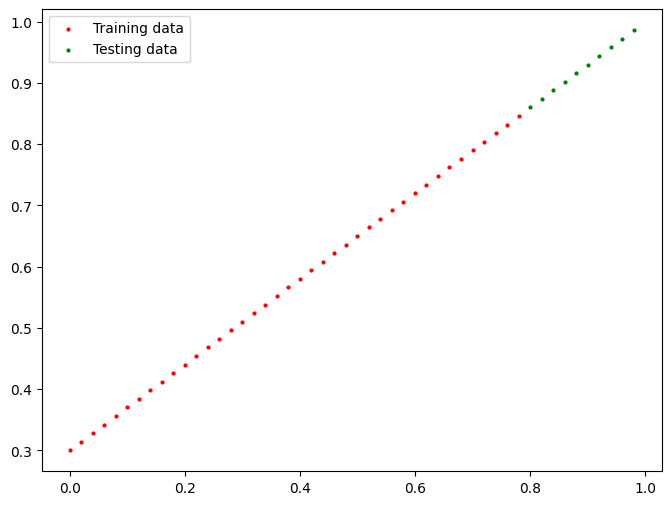

In [31]:
plot_train_test_data()

#### Build a model 

What the model does:
- Start with randorm values (weights and bias)
-  Look at training data and adjust the random values to better represent (or get closer to) the ideal values

How to do so?
- Gradient descent
- Backpropagation 

In [23]:
# Create a linear regression model

class LinearRegressionModel(nn.Module): # Almost everything in PyTorch inhertis from nn.Module 
    def __init__(self):
        super().__init__()
        # Define the weight and bias parameter (Initialization of the model parameters)
        self.weights = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
        self.bias =  nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))

        '''
        requires_grad=True means PyTorch will track the gradients of the specific parameter for 
        use with torch.autograd and gradient descent(for many torch.nn) modules, requires_grad=True
        is set by default
        '''

        # Forward method to define the computation in the model 
        # any subclass of nn.Module is need to override forward() method
    def forward(self,x: torch.Tensor) -> torch.Tensor: # <- x is the input data
        return self.weights * x + self.bias # y = mx+b
    

    
        
        
    

#### PyTorch Model building essentials class 
- torch.nn -> Contains all of the building for computational graphs (a neural network can be considered as a computational graph)
- torch.nn.Parameter -> what parameters should out model try and learn, often a PyTorch layer from torch.nn will set these for us
- torch.nn.Module -> The base class for all neural network modules, if you subclass it, you should override the `forward()` method
- torch.optim -> This where the optimizers in PyTorch live, they help with gradient descent
- torch.utils.data.Dataset -> Represents a map between key(label) and sample(features) pairs of your data.Such as images and thier associated labels.
- torch.utils.data.DataLoader -> Creates a Python iterable over a torch Dataset(allows you to iterate over your data)
- `def forward()` -> All `nn.Module` subclasses require you to overwirte `forward()`, this method defines what happens in the forward computation

In [24]:
# Create a random Seed 
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)

# Craete an instance of the model 
model_0 = LinearRegressionModel()

# Checkout the parameters
list(model_0.parameters())


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [25]:
# List named Parametes
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [26]:
weight,bias

(0.7, 0.3)

#### Making prediction using `torch.inference_mode()`

To check out model's predictive power. 

When we pass data through our model, it will run the data through `forward()` method

In [27]:
X_test,y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [36]:
# Make prediction with model
# inference_mode() <--- Disable all gradient descent 
with torch.inference_mode():
    y_preds = model_0(X_test)
y_preds

# Same thing with torch.no_grad() but inference_mode() is preferd
#with torch.no_grad():
#    y_preds = model_0(X_test)

#y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

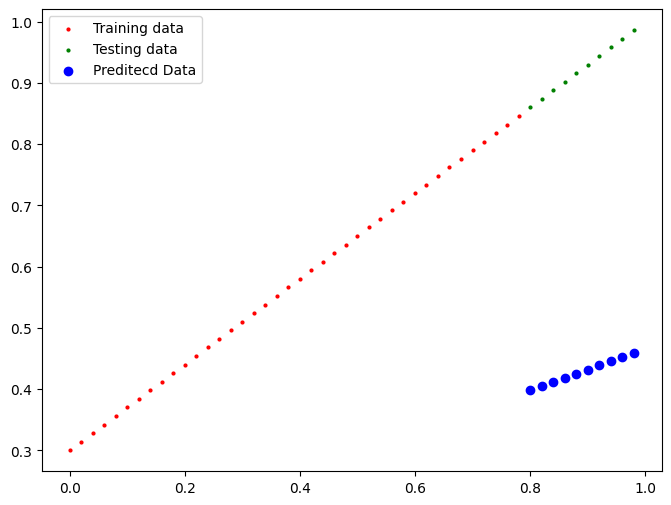

In [37]:
plot_train_test_data(prediction=y_preds)

#### Train Model
The whole idea of training is for a model to move from some unknown parameters(these may be random) to some known parameters.
Or in other words from a poor representation of the data to a better representation of data.

**Loss function** One way to measuer how 